In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Paths
PROJECT_ROOT = Path("..")
CSV_PATH = PROJECT_ROOT / "data" / "metadata" / "labels.csv"
MODEL_SAVE_PATH = PROJECT_ROOT / "models" / "baseline_resnet18_temporal.pth"

# Make sure models folder exists
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

# Training config
IMAGE_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 8
LEARNING_RATE = 1e-4
NUM_CLASSES = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [3]:
df = pd.read_csv(CSV_PATH)
df.head()

,image_path,banana_type,banana_id,day_index,days_left,stage,stage_name,original_split,split
0,data/raw/test/nendranbanana/nendranbanana_1_1.jpg,nendranbanana,nendranbanana_banana_1,1,7,0,Early,test,train
1,data/raw/test/nendranbanana/nendranbanana_1_2.jpg,nendranbanana,nendranbanana_banana_1,2,6,0,Early,test,train
2,data/raw/test/nendranbanana/nendranbanana_1_3.jpg,nendranbanana,nendranbanana_banana_1,3,5,1,Early-Mid,test,train
3,data/raw/test/nendranbanana/nendranbanana_1_4.jpg,nendranbanana,nendranbanana_banana_1,4,4,2,Mid,test,train
4,data/raw/test/nendranbanana/nendranbanana_1_5.jpg,nendranbanana,nendranbanana_banana_1,5,3,2,Mid,test,train


In [4]:
print("Total images:", len(df))
print("Unique banana types:", df["banana_type"].nunique())
print("Unique banana IDs:", df["banana_id"].nunique())
print("\nSplit counts:")
print(df["split"].value_counts())
print("\nStage counts:")
print(df["stage_name"].value_counts())
print("\nDays-left counts:")
print(df["days_left"].value_counts().sort_index())

Total images: 320
Unique banana types: 5
Unique banana IDs: 20

Split counts:
split
train    160
val       80
test      80
Name: count, dtype: int64

Stage counts:
stage_name
Early        80
Mid          80
End-stage    80
Early-Mid    40
Late         40
Name: count, dtype: int64

Days-left counts:
days_left
0    40
1    40
2    40
3    40
4    40
5    40
6    40
7    40
Name: count, dtype: int64


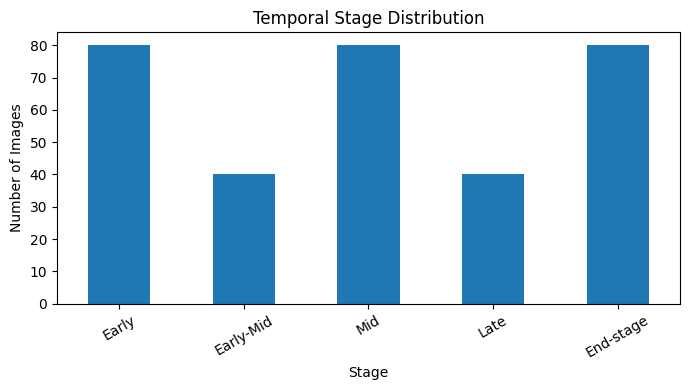

In [5]:
plt.figure(figsize=(7, 4))
df["stage_name"].value_counts().reindex(
    ["Early", "Early-Mid", "Mid", "Late", "End-stage"]
).plot(kind="bar")
plt.title("Temporal Stage Distribution")
plt.xlabel("Stage")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

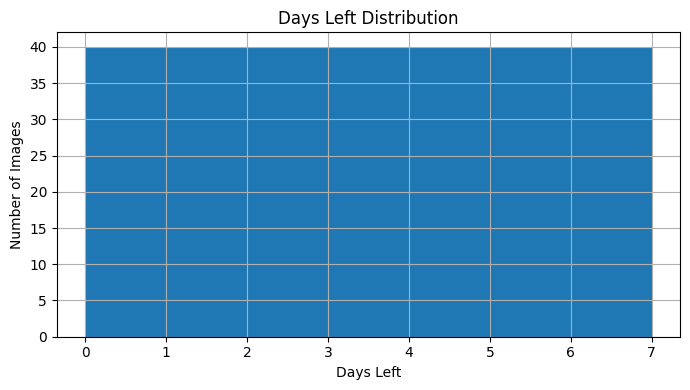

In [6]:
plt.figure(figsize=(7, 4))
df["days_left"].hist(bins=8)
plt.title("Days Left Distribution")
plt.xlabel("Days Left")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [7]:
ordered_stage_names = ["Early", "Early-Mid", "Mid", "Late", "End-stage"]

sample_rows = (
    df.groupby("stage_name", group_keys=False)
      .head(2)
      .reset_index(drop=True)
)

sample_rows[["image_path", "stage_name", "days_left"]]

,image_path,stage_name,days_left
0,data/raw/test/nendranbanana/nendranbanana_1_1.jpg,Early,7
1,data/raw/test/nendranbanana/nendranbanana_1_2.jpg,Early,6
2,data/raw/test/nendranbanana/nendranbanana_1_3.jpg,Early-Mid,5
3,data/raw/test/nendranbanana/nendranbanana_1_4.jpg,Mid,4
4,data/raw/test/nendranbanana/nendranbanana_1_5.jpg,Mid,3
5,data/raw/test/nendranbanana/nendranbanana_1_6.jpg,Late,2
6,data/raw/test/nendranbanana/nendranbanana_1_7.jpg,End-stage,1
7,data/raw/test/nendranbanana/nendranbanana_1_8.jpg,End-stage,0
8,data/raw/test/nendranbanana/nendranbanana_2_3.jpg,Early-Mid,5
9,data/raw/test/nendranbanana/nendranbanana_2_6.jpg,Late,2


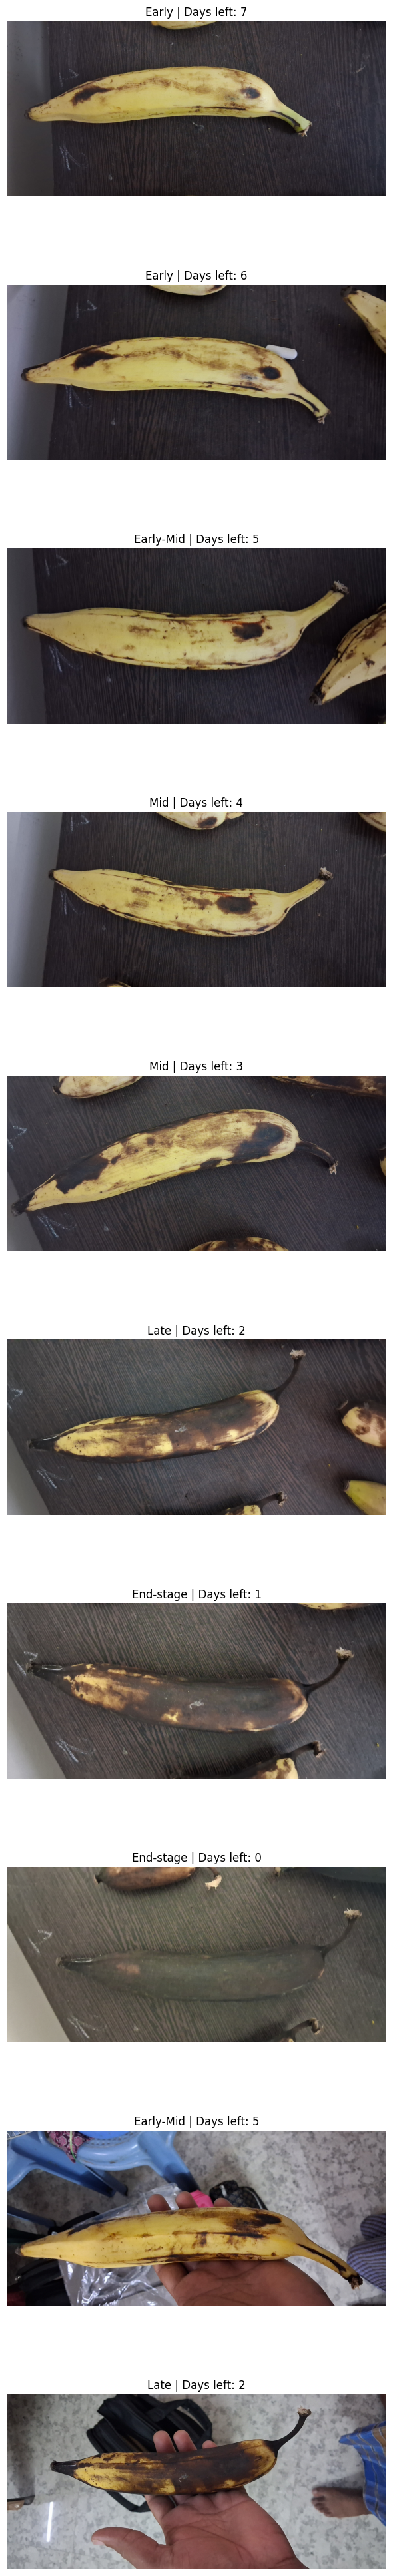

In [8]:
fig, axes = plt.subplots(len(sample_rows), 1, figsize=(6, 4 * len(sample_rows)))

if len(sample_rows) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = Image.open(PROJECT_ROOT / row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{row['stage_name']} | Days left: {row['days_left']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
class BananaTemporalDataset(Dataset):
    def __init__(self, csv_path, split, transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.transform = transform

        if self.df.empty:
            raise ValueError(f"No rows found for split='{split}'")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(PROJECT_ROOT / row["image_path"]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        stage = torch.tensor(int(row["stage"]), dtype=torch.long)
        days_left = torch.tensor(float(row["days_left"]), dtype=torch.float32)

        return {
            "image": image,
            "stage": stage,
            "days_left": days_left,
            "banana_id": row["banana_id"],
            "banana_type": row["banana_type"],
            "image_path": row["image_path"],
        }

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [11]:
train_ds = BananaTemporalDataset(CSV_PATH, split="train", transform=train_transform)
val_ds = BananaTemporalDataset(CSV_PATH, split="val", transform=eval_transform)
test_ds = BananaTemporalDataset(CSV_PATH, split="test", transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

Train size: 160
Val size: 80
Test size: 80


In [12]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pakhi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:03<00:00, 12.3MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    all_preds = []
    all_targets = []
    losses = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            targets = batch["stage"].to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            losses.append(loss.item())

            preds = outputs.argmax(dim=1).cpu().numpy()
            targets_np = targets.cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(targets_np)

    avg_loss = float(np.mean(losses))
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, f1, np.array(all_targets), np.array(all_preds)

In [14]:
best_val_f1 = -1.0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for batch in train_loader:
        images = batch["image"].to(DEVICE)
        targets = batch["stage"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_loss, val_acc, val_f1, _, _ = evaluate_classifier(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved best model to {MODEL_SAVE_PATH}")

Epoch 1/8 | Train Loss: 1.3175 | Val Loss: 1.1756 | Val Acc: 0.4750 | Val F1: 0.3710
Saved best model to ..\models\baseline_resnet18_temporal.pth
Epoch 2/8 | Train Loss: 0.7533 | Val Loss: 1.0514 | Val Acc: 0.4875 | Val F1: 0.3947
Saved best model to ..\models\baseline_resnet18_temporal.pth
Epoch 3/8 | Train Loss: 0.4227 | Val Loss: 1.1642 | Val Acc: 0.4875 | Val F1: 0.3634
Epoch 4/8 | Train Loss: 0.3605 | Val Loss: 1.3090 | Val Acc: 0.5250 | Val F1: 0.4441
Saved best model to ..\models\baseline_resnet18_temporal.pth
Epoch 5/8 | Train Loss: 0.2348 | Val Loss: 1.0918 | Val Acc: 0.5500 | Val F1: 0.4641
Saved best model to ..\models\baseline_resnet18_temporal.pth
Epoch 6/8 | Train Loss: 0.2143 | Val Loss: 1.2206 | Val Acc: 0.4875 | Val F1: 0.4091
Epoch 7/8 | Train Loss: 0.2001 | Val Loss: 1.2089 | Val Acc: 0.4875 | Val F1: 0.3599
Epoch 8/8 | Train Loss: 0.2171 | Val Loss: 1.1884 | Val Acc: 0.5000 | Val F1: 0.4497


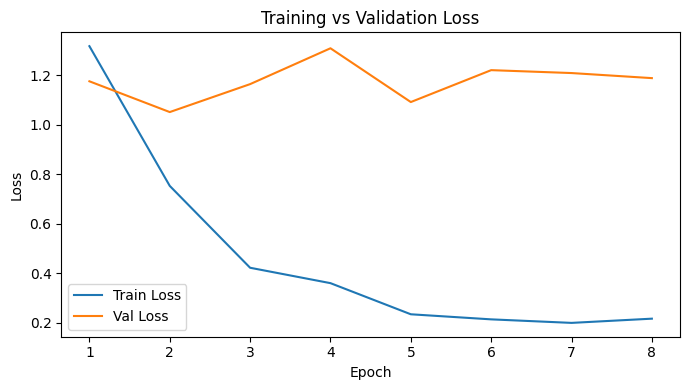

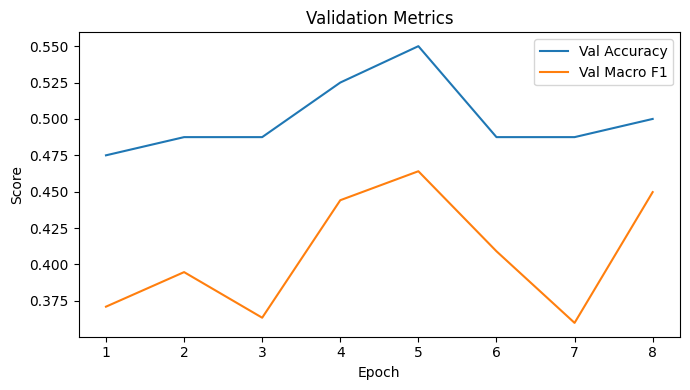

In [15]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.plot(epochs_range, history["val_f1"], label="Val Macro F1")
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
best_model = models.resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES)
best_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
best_model = best_model.to(DEVICE)

test_loss, test_acc, test_f1, y_true, y_pred = evaluate_classifier(
    best_model, test_loader, criterion, DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")

Test Loss: 1.2091
Test Accuracy: 0.4875
Test Macro F1: 0.3629


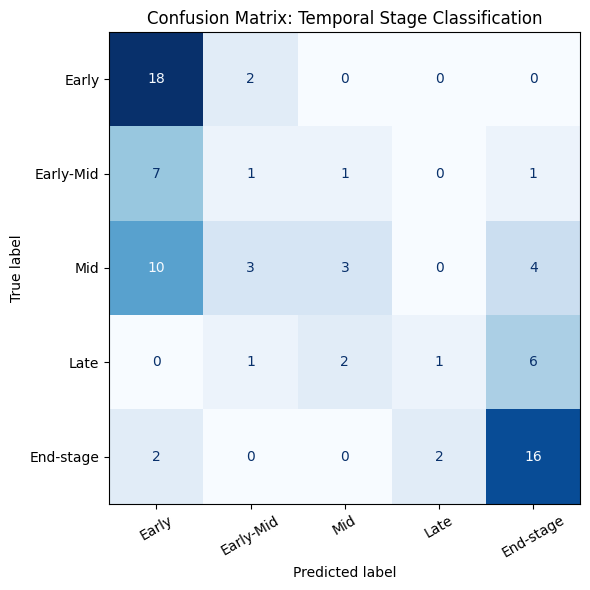

In [17]:
label_order = [0, 1, 2, 3, 4]
label_names = ["Early", "Early-Mid", "Mid", "Late", "End-stage"]

cm = confusion_matrix(y_true, y_pred, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=30, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Temporal Stage Classification")
plt.tight_layout()
plt.show()

In [18]:
stage_to_days_left = {
    0: 6.5,  # Early
    1: 5.0,  # Early-Mid
    2: 3.5,  # Mid
    3: 2.0,  # Late
    4: 0.5,  # End-stage
}

In [19]:
best_model.eval()

predicted_stage_list = []
true_days_left_list = []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(DEVICE)
        outputs = best_model(images)
        pred_stage = outputs.argmax(dim=1).cpu().numpy()

        predicted_stage_list.extend(pred_stage.tolist())
        true_days_left_list.extend(batch["days_left"].numpy().tolist())

pred_days_left = np.array([stage_to_days_left[s] for s in predicted_stage_list], dtype=float)
true_days_left = np.array(true_days_left_list, dtype=float)

mae = np.mean(np.abs(pred_days_left - true_days_left))
rmse = np.sqrt(np.mean((pred_days_left - true_days_left) ** 2))

print(f"Baseline Days-Left MAE: {mae:.4f}")
print(f"Baseline Days-Left RMSE: {rmse:.4f}")

Baseline Days-Left MAE: 1.3750
Baseline Days-Left RMSE: 1.8422


In [20]:
results_df = pd.DataFrame({
    "true_stage": y_true,
    "pred_stage": y_pred,
})

stage_names = ["Early", "Early-Mid", "Mid", "Late", "End-stage"]
results_df["true_stage_name"] = results_df["true_stage"].map(lambda x: stage_names[x])
results_df["pred_stage_name"] = results_df["pred_stage"].map(lambda x: stage_names[x])

results_df.head(10)

,true_stage,pred_stage,true_stage_name,pred_stage_name
0,0,0,Early,Early
1,0,0,Early,Early
2,1,0,Early-Mid,Early
3,2,0,Mid,Early
4,2,4,Mid,End-stage
5,3,4,Late,End-stage
6,4,4,End-stage,End-stage
7,4,4,End-stage,End-stage
8,0,0,Early,Early
9,0,0,Early,Early
